# Problemas de distribución de probabilidad

## Distribución binomial

En teoría de la probabilidad y estadística, la distribución binomial es la distribución de probabilidad discreta que da sólo dos resultados posibles en un experimento; por ejemplo, al lanzar una moneda, puede salir cara o cruz.

In [65]:
from scipy.stats import binom

# Definir todas las funciones de probabilidad relacionadas con esta distribución.

def dbinom(x, size, prob = 0.5):
    """
    Calcula la estimación puntual de la distribución binomial.
    """
    result = binom.pmf(k = x, n = size, p = prob, loc = 0)

    return result

def pbinom(q, size, prob = 0.5):
    """
    Calcula el acumulado de la distribución binomial.
    """
    result = binom.cdf(k = q, n = size, p = prob, loc = 0)

    return result

def qbinom(p, size, prob = 0.5):
    """
    Calcula la función cuantil a partir de la distribución binomial.
    """
    result = binom.ppf(q = p, n = size, p = prob, loc = 0)

    return result

def rbinom(n, size, prob = 0.5):
    """
    Genera variables aleatorias a partir de la distribución binomial.
    """
    result = binom.rvs(n = size, p = prob, size = n)

    return result

In [66]:
# Distribución binomial(10, 0.2), dónde n = 10 es el número de ensayos y p = 0.2 es la probabilidad de éxito en un solo ensayo
import numpy as np

np.random.seed(42)

print(f"Probability that a Binomial(10, 0.2) takes the value 2: {dbinom(2, size = 10, prob = 0.2)}")
print(f"Probability that a Binomial(10, 0.2) will take a value less than 2: {pbinom(2, size = 10, prob = 0.2)}")
print(f"Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? {qbinom(0.9, size = 10, prob = 0.2)}")
print(f"Generate 2000 random values from a Binomial(10, 0.2) distribution: {rbinom(2000, size = 10, prob = 0.2)}")

Probability that a Binomial(10, 0.2) takes the value 2: 0.30198988800000004
Probability that a Binomial(10, 0.2) will take a value less than 2: 0.6777995263999997
Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? 4.0
Generate 2000 random values from a Binomial(10, 0.2) distribution: [1 4 3 ... 0 0 1]


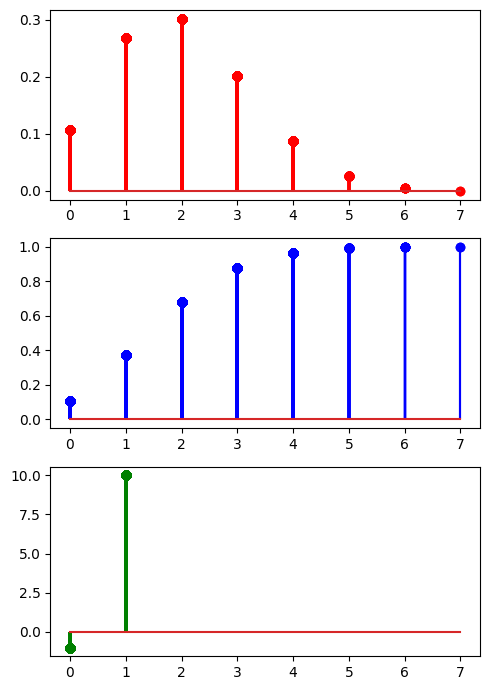

In [67]:
import matplotlib.pyplot as plt

np.random.seed(42)

size = 10
prob = 0.2
data = rbinom(2000, size = 10, prob = 0.2)

pmf = dbinom(data, size = size, prob = prob)
cdf = pbinom(data, size = size, prob = prob)
ppf = qbinom(data, size = size, prob = prob)

fig, axis = plt.subplots(3, 1, figsize = (5, 7))

axis[0].stem(data, pmf, "r-")
axis[1].stem(data, cdf, "b-")
axis[2].stem(data, ppf, "g-")

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

## Ejercicio 1

Escriba las funciones anteriores pero para distribuciones normales y uniformes.

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform

Funciones para distribución normal

In [74]:
def dnorm(x, mean=0, std=1):
    """
    Calcula la densidad de la distribución normal.
    """
    return norm.pdf(x, loc=mean, scale=std)

def pnorm(x, mean=0, std=1):
    """
    Calcula el acumulado de la distribución normal.
    """
    return norm.cdf(x, loc=mean, scale=std)

def qnorm(p, mean=0, std=1):
    """
    Calcula la función cuantil a partir de la distribución normal.
    """
    return norm.ppf(p, loc=mean, scale=std)

def rnorm(n, mean=0, std=1):
    """
    Genera variables aleatorias a partir de la distribución normal.
    """
    return norm.rvs(size=n, loc=mean, scale=std)

Visualización de distribución normal

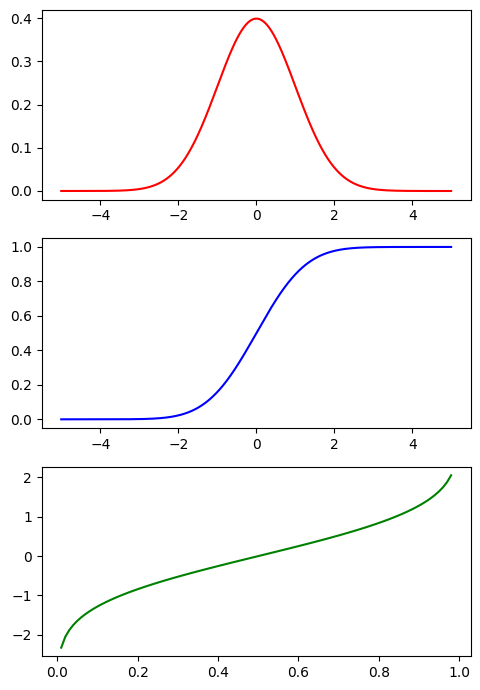

In [82]:
mean = 0
std = 1
data_norm = np.arange(-5, 5, 0.01)
prob_range_norm = np.arange(0.01, 0.99, 0.01)

pdf_norm = dnorm(data_norm, mean=mean, std=std)
cdf_norm = pnorm(data_norm, mean=mean, std=std)
ppf_norm = qnorm(prob_range_norm)

fig, axis = plt.subplots(3, 1, figsize=(5, 7))

axis[0].plot(data_norm, pdf_norm, "r-", linewidth=1.5)
axis[1].plot(data_norm, cdf_norm, "b-", linewidth=1.5)
axis[2].plot(prob_range_norm, ppf_norm, "g-", linewidth=1.5)

plt.tight_layout()
plt.show()

La distribución normal tiene forma de campana simétrica centrada en la media (0). La PDF muestra que los valores cercanos a 0 son los más probables. La CDF sube de forma suave en S, mostrando cómo se acumula la probabilidad. La PPF es la inversa de la CDF: dado un porcentaje, devuelve el valor correspondiente — por ejemplo, `qnorm(0.975)` devuelve 1.96, el z-score que aparece en todos los intervalos de confianza del 95%.

Funciones para distribución uniforme

In [76]:
def dunif(x, low=0, high=1):
    """
    Calcula la densidad de la distribución uniforme.
    """
    return uniform.pdf(x, loc=low, scale=(high - low))

def punif(q, low=0, high=1):
    """
    Calcula el acumulado de la distribución uniforme.
    """
    return uniform.cdf(q, loc=low, scale=(high - low))

def qunif(p, low=0, high=1):
    """
    Calcula la función cuantil a partir de la distribución uniforme.
    """
    return uniform.ppf(p, loc=low, scale=(high - low))

def runif(n, low=0, high=1):
    """
    Genera variables aleatorias a partir de la distribución uniforme.
    """
    return uniform.rvs(loc=low, scale=(high - low), size=n)

Visualización de distribución uniforme

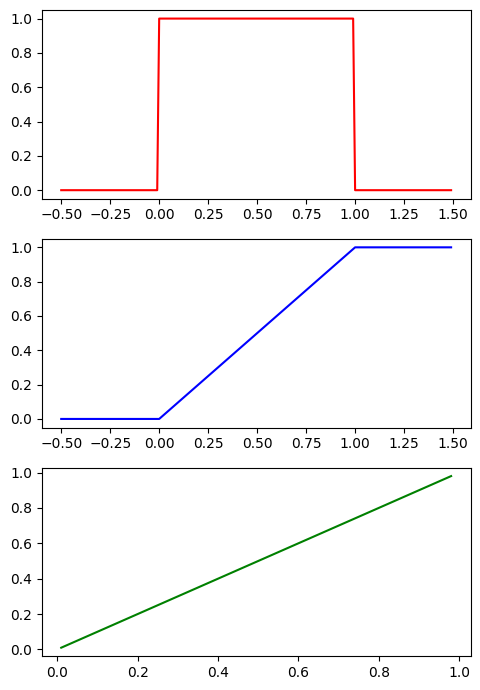

In [78]:
low = 0
high = 1
data_unif = np.arange(-0.5, 1.5, 0.01)
prob_range_unif = np.arange(0.01, 0.99, 0.01)

pdf_unif = dunif(data_unif, low=low, high=high)
cdf_unif = punif(data_unif, low=low, high=high)
ppf_unif = qunif(prob_range_unif, low=low, high=high)

fig, axis = plt.subplots(3, 1, figsize=(5, 7))

axis[0].plot(data_unif, pdf_unif, "r-", linewidth=1.5)
axis[1].plot(data_unif, cdf_unif, "b-", linewidth=1.5)
axis[2].plot(prob_range_unif, ppf_unif, "g-", linewidth=1.5)

plt.tight_layout()
plt.show()

La distribución uniforme asigna la misma probabilidad a todos los valores dentro del intervalo [0, 1]. La PDF es una línea horizontal constante en 1.0 — todos los valores son igual de probables. La CDF sube de forma completamente lineal, lo que tiene sentido: si todos los valores son equiprobables, la probabilidad acumulada crece a ritmo constante. La PPF es una diagonal perfecta — el cuantil 0.6 es exactamente el valor 0.6.